## Support Vector Machine (Regression)

In [2]:
#import needed packages
import pandas as pd
import numpy as np
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt

In [3]:
#grab the data
X_train = pd.read_csv("../data/X_train_data.csv")
y_train = pd.read_csv("../data/Y_train_data.csv")

In [4]:
#further split the data to obtain a new training and testing set
X_train_svm, X_test_svm, y_train_svm, y_test_svm = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

In [5]:
#Support vector machine pipeline
svr = Pipeline([
    ("scaler", StandardScaler()),
    ("svr", SVR())
])

In [6]:
#create the possible parameter dict
parameter_grid_svr = {"svr__kernel": ["linear", "rbf"], "svr__C": [0.1, 1.0], "svr__epsilon": [0.01, 0.1]}
#find best parameter
grid_search_ridge = GridSearchCV(svr, parameter_grid_svr)
grid_search_ridge.fit(X_train_svm, y_train_svm.values.ravel())
print(grid_search_ridge.best_params_)

{'svr__C': 1.0, 'svr__epsilon': 0.1, 'svr__kernel': 'rbf'}


In [7]:
#grab all the optimal parameters
best_kernel = grid_search_ridge.best_params_["svr__kernel"]
best_C = grid_search_ridge.best_params_["svr__C"]
best_epsilon = grid_search_ridge.best_params_["svr__epsilon"]

In [8]:
#incorporate the optimal parameters into the dict
svr_improved = Pipeline([
    ("scaler", StandardScaler()),
    ("svr", SVR(kernel = best_kernel, C = best_C, epsilon = best_epsilon))
])

In [9]:
#fit the data to the optimized model
improved = svr_improved.fit(X_train_svm, y_train_svm.values.ravel())

In [10]:
#make predictions
y_pred = svr_improved.predict(X_test_svm)

In [11]:
#score
r2 = r2_score(y_test_svm, y_pred) # Score on the test set
print("R2 is equal to:", r2)
#score
MSE = mean_squared_error(y_test_svm, y_pred) # Score on the test set
print("MSE is eqaul to: ", MSE)
#score
rmse = np.sqrt(MSE)
print("SVR RMSE:", rmse)

R2 is equal to: 0.7154515105532457
MSE is eqaul to:  0.2285117020230074
SVR RMSE: 0.4780289761332543


In [14]:
y_pred

array([6.02783041, 7.40350931, 7.08825881, ..., 6.63489571, 5.8701093 ,
       7.46854143], shape=(1967,))

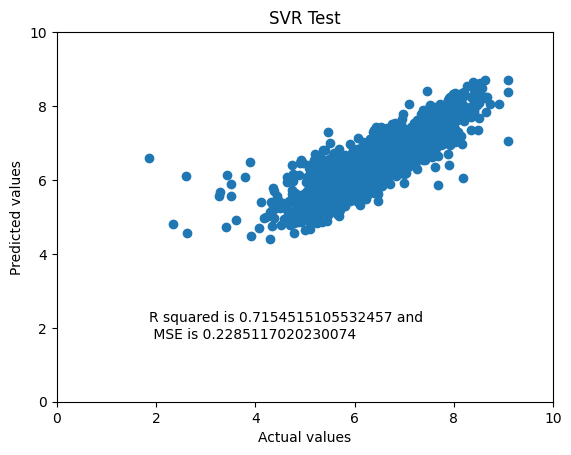

In [25]:
#plot the SVR
plt.scatter(y_test_svm.Score, y_pred)
plt.xlim((0, 10))
plt.ylim((0, 10))
plt.title("SVR Test")
plt.xlabel("Actual values")
plt.ylabel("Predicted values")
#add in the performance metrics
plt.text(x = min(y_test_svm.Score), y= max(y_pred)-7,s = f"R squared is {r2} and \n MSE is {MSE}")
plt.savefig("../outputs/svr.png")
plt.show()